# OCR et extraction de champs

**Objectif** : explorer interactivement la sortie brute de l'OCR sur un document
d'exemple, et ajuster les règles d'extraction (`field_extractor.py`) avant de les
figer dans le pipeline CLI/Streamlit.

Dépose un document de test (facture, ticket...) dans `data/sample_documents/`
avant de lancer ce notebook.

**Pas d'entraînement ici** : le projet utilise EasyOCR pré-entraîné (zero-shot),
tout l'effort de personnalisation porte sur les règles d'extraction de champs.


In [1]:
import sys
sys.path.append("../src")

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ocr_engine import OCREngine, draw_ocr_boxes
from field_extractor import extract_fields, _normalize_text_blocks, fields_to_highlight_set

DOC_PATH = "../data/image.png"  # <- adapte au nom de ton document de test
assert Path(DOC_PATH).exists(), f"Dépose un document de test dans data/ (attendu: {DOC_PATH})"


## 1.Chargement de OCR

In [2]:
engine = OCREngine(languages=["fr", "en"], gpu=False)

pages = engine.run_on_file(DOC_PATH);
image, ocr_results = pages[0]  # première page

print(f"{len(ocr_results)} blocs de texte détectés")
for item in ocr_results[:10]:
    print(f"  conf={item['confidence']:.2f}  texte='{item['text']}'")


Using CPU. Note: This module is much faster with a GPU.
z:\Personal project\Computer_Vision\OCR\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
z:\Personal project\Computer_Vision\OCR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


50 blocs de texte détectés
  conf=1.00  texte='Walmart'
  conf=0.51  texte='Savemoncy. Live better'
  conf=1.00  texte='970-728-1838'
  conf=0.41  texte='Mar JIM JAMES'
  conf=0.89  texte='1155 $ CAHINO DEL RIO'
  conf=0.63  texte='DURANGO, Co 81303'
  conf=0.42  texte='ST#   5944'
  conf=0.82  texte='OP# 39934962'
  conf=0.79  texte='TE#  17'
  conf=0.74  texte='TR#   14322'


In [3]:
ocr_results[10:20]

[{'bbox': [(14, 216), (148, 216), (148, 240), (14, 240)],
  'text': 'HDHI 6FT CABLE',
  'confidence': 0.6897189138610267},
 {'bbox': [(318, 216), (378, 216), (378, 240), (318, 240)],
  'text': '418,99',
  'confidence': 0.39109657967412137},
 {'bbox': [(17, 239), (181, 239), (181, 259), (17, 259)],
  'text': 'HARMONY   UNV   REMOTE',
  'confidence': 0.6307157342422592},
 {'bbox': [(311, 239), (377, 239), (377, 259), (311, 259)],
  'text': '4189,99',
  'confidence': 0.5372474074669652},
 {'bbox': [(144, 280), (218, 280), (218, 304), (144, 304)],
  'text': 'SUBTOTAL',
  'confidence': 0.9450192122213686},
 {'bbox': [(310, 280), (378, 280), (378, 304), (310, 304)],
  'text': '4208 ,98',
  'confidence': 0.4966875761188956},
 {'bbox': [(145, 303), (177, 303), (177, 323), (145, 323)],
  'text': 'TAx',
  'confidence': 0.7290894065178259},
 {'bbox': [(319, 303), (377, 303), (377, 323), (319, 323)],
  'text': '$13.37',
  'confidence': 0.5808077335295926},
 {'bbox': [(147, 325), (193, 325), (193, 

## 2.visualisation

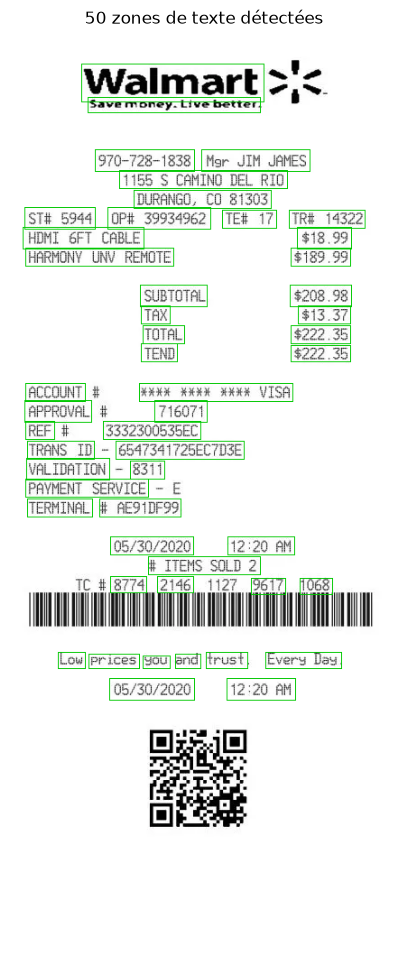

In [4]:
annotated = draw_ocr_boxes(image, ocr_results)

plt.figure(figsize=(10, 12))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"{len(ocr_results)} zones de texte détectées")
plt.axis("off")
plt.show()


## 3. Inspection ligne par ligne (regroupement utilisé par l'extracteur)

In [5]:
blocks = _normalize_text_blocks(ocr_results)
for b in blocks:
    print(f"y={b['y']:4d}  x={b['x']:4d}  conf={b['confidence']:.2f}  '{b['text']}'")


y=  35  x=  79  conf=1.00  'Walmart'
y=  72  x=  86  conf=0.51  'Savemoncy. Live better'
y= 130  x=  94  conf=1.00  '970-728-1838'
y= 130  x= 212  conf=0.41  'Mar JIM JAMES'
y= 153  x= 121  conf=0.89  '1155 $ CAHINO DEL RIO'
y= 175  x= 137  conf=0.63  'DURANGO, Co 81303'
y= 194  x=  16  conf=0.42  'ST#   5944'
y= 194  x= 108  conf=0.82  'OP# 39934962'
y= 197  x= 235  conf=0.79  'TE#  17'
y= 197  x= 309  conf=0.74  'TR#   14322'
y= 216  x=  14  conf=0.69  'HDHI 6FT CABLE'
y= 216  x= 318  conf=0.39  '418,99'
y= 239  x=  17  conf=0.63  'HARMONY   UNV   REMOTE'
y= 239  x= 311  conf=0.54  '4189,99'
y= 280  x= 144  conf=0.95  'SUBTOTAL'
y= 280  x= 310  conf=0.50  '4208 ,98'
y= 303  x= 145  conf=0.73  'TAx'
y= 303  x= 319  conf=0.58  '$13.37'
y= 325  x= 147  conf=0.96  'TOTAL'
y= 325  x= 311  conf=0.83  '4222,35'
y= 345  x= 145  conf=1.00  'TEND'
y= 347  x= 311  conf=0.38  '4222.35'
y= 389  x=  17  conf=0.78  'ACCOUNT'
y= 389  x= 143  conf=0.14  'Kxx* **** #*x* VISA'
y= 408  x=  16  conf=0.47

In [6]:
blocks[15:25]

[{'text': '4208 ,98',
  'confidence': 0.4966875761188956,
  'x': 310,
  'y': 280,
  'bbox': [(310, 280), (378, 280), (378, 304), (310, 304)]},
 {'text': 'TAx',
  'confidence': 0.7290894065178259,
  'x': 145,
  'y': 303,
  'bbox': [(145, 303), (177, 303), (177, 323), (145, 323)]},
 {'text': '$13.37',
  'confidence': 0.5808077335295926,
  'x': 319,
  'y': 303,
  'bbox': [(319, 303), (377, 303), (377, 323), (319, 323)]},
 {'text': 'TOTAL',
  'confidence': 0.9630141981442757,
  'x': 147,
  'y': 325,
  'bbox': [(147, 325), (193, 325), (193, 345), (147, 345)]},
 {'text': '4222,35',
  'confidence': 0.828147590864152,
  'x': 311,
  'y': 325,
  'bbox': [(311, 325), (377, 325), (377, 345), (311, 345)]},
 {'text': 'TEND',
  'confidence': 0.9985662698745728,
  'x': 145,
  'y': 345,
  'bbox': [(145, 345), (185, 345), (185, 365), (145, 365)]},
 {'text': '4222.35',
  'confidence': 0.37940742409162714,
  'x': 311,
  'y': 347,
  'bbox': [(311, 347), (377, 347), (377, 365), (311, 365)]},
 {'text': 'ACCO

## 4. Extraction des champs structurés

In [7]:
fields = extract_fields(ocr_results)
for k, v in fields.items():
    print(f"{k:25s}: {v}")


numero_facture           : None
date                     : 05/30/2020
montant_total            : 4222,35
tva                      : 13.37
fournisseur              : Walmart
confiance_ocr_moyenne    : 0.751
nb_blocs_texte_detectes  : 50


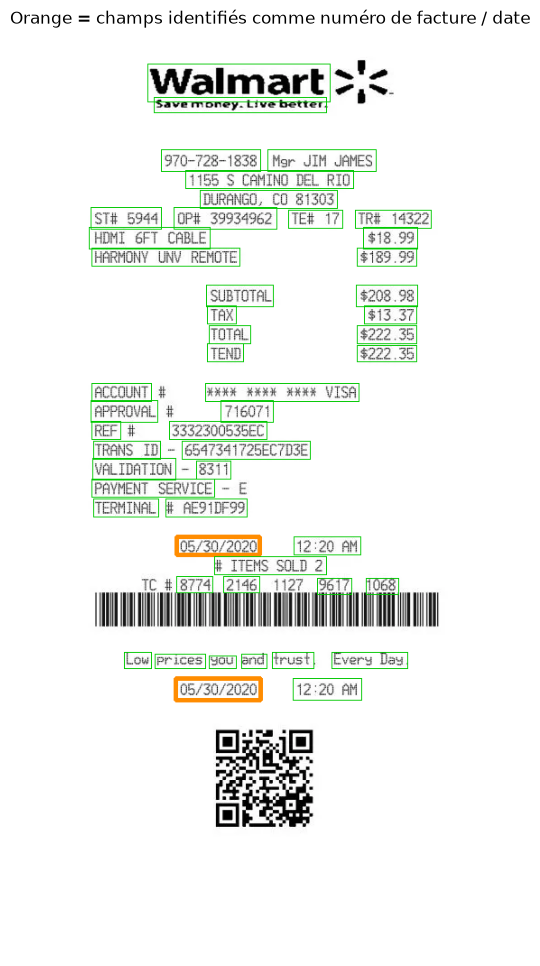

In [8]:
highlight = fields_to_highlight_set(fields, ocr_results)
annotated_highlighted = draw_ocr_boxes(image, ocr_results, highlight_texts=highlight)

plt.figure(figsize=(10, 12))
plt.imshow(cv2.cvtColor(annotated_highlighted, cv2.COLOR_BGR2RGB))
plt.title("Orange = champs identifiés comme numéro de facture / date")
plt.axis("off")
plt.show()
